Load, reduce, and prepare a real dataset

Explained variance retained: 0.632


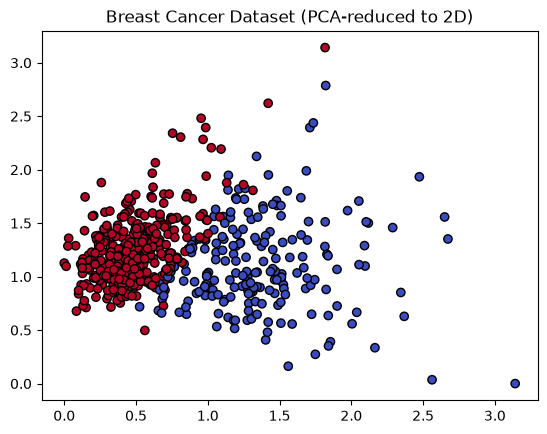

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load real dataset: 569 patients, 30 features, label = malignant/benign
data = load_breast_cancer()
X_raw, y = data.data, data.target

# Standardize first — PCA is sensitive to feature scale, and these 30 features
# are on very different scales (e.g. "mean radius" vs "mean area")
X_scaled = StandardScaler().fit_transform(X_raw)

# Reduce 30 features -> 2 principal components (quantum circuits here use 2 qubits)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

# Rescale into [0, pi] for angle encoding — same reason as before
X = MinMaxScaler((0, np.pi)).fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Breast Cancer Dataset (PCA-reduced to 2D)")
plt.show()

Build the quantum feature map

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement="linear")
print(feature_map.decompose().draw())

   ┌────────────┐┌───────────────┐                                         »
0: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──────────────────────────────────────»
   ├────────────┤├───────────────┤┌─┴─┐┌──────────────────────────────────┐»
1: ┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├»
   └────────────┘└───────────────┘└───┘└──────────────────────────────────┘»
«        ┌────────────┐┌───────────────┐     »
«0: ──■──┤ U(π/2,0,π) ├┤ U(0,0,2*x[0]) ├──■──»
«   ┌─┴─┐├────────────┤├───────────────┤┌─┴─┐»
«1: ┤ X ├┤ U(π/2,0,π) ├┤ U(0,0,2*x[1]) ├┤ X ├»
«   └───┘└────────────┘└───────────────┘└───┘»
«                                            
«0: ──────────────────────────────────────■──
«   ┌──────────────────────────────────┐┌─┴─┐
«1: ┤ U(0,0,(-π + x[0])*(-π + x[1])*2) ├┤ X ├
«   └──────────────────────────────────┘└───┘


Build the quantum kernel

In [ ]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

Visualize the kernel matrix

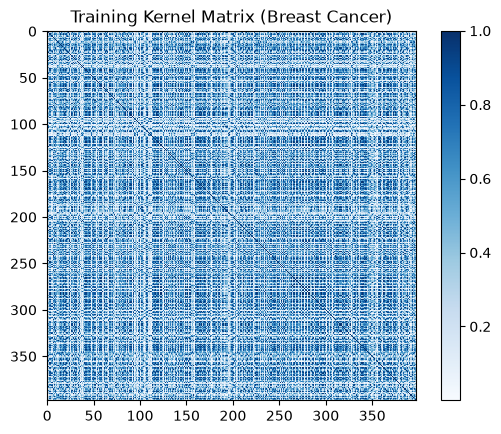

In [ ]:
matrix_train = quantum_kernel.evaluate(x_vec=X_train)

plt.imshow(matrix_train, interpolation="nearest", origin="upper", cmap="Blues")
plt.title("Training Kernel Matrix (Breast Cancer)")
plt.colorbar()
plt.show()

Train QSVC and evaluate

In [ ]:
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)

train_score = qsvc.score(X_train, y_train)
test_score = qsvc.score(X_test, y_test)

print(f"QSVC training accuracy: {train_score:.3f}")
print(f"QSVC test accuracy: {test_score:.3f}")

QSVC training accuracy: 0.874
QSVC test accuracy: 0.895


Baseline comparison (classical SVM)

In [2]:
from sklearn.svm import SVC

classical_svc = SVC(kernel="rbf")
classical_svc.fit(X_train, y_train)
print(f"Classical RBF-SVM test accuracy: {classical_svc.score(X_test, y_test):.3f}")

Classical RBF-SVM test accuracy: 0.959


Build the circuit: feature map + ansatz

In [6]:
from qiskit.circuit.library import zz_feature_map, real_amplitudes

num_qubits = 2
feature_map_pqc = zz_feature_map(num_qubits, reps=1)
ansatz = real_amplitudes(num_qubits, reps=2)

print(ansatz.decompose().draw())  # using text drawer to avoid the pylatexenc issue

     ┌─────────────┐     ┌─────────────┐     ┌─────────────┐
q_0: ┤ R(θ[0],π/2) ├──■──┤ R(θ[2],π/2) ├──■──┤ R(θ[4],π/2) ├
     ├─────────────┤┌─┴─┐├─────────────┤┌─┴─┐├─────────────┤
q_1: ┤ R(θ[1],π/2) ├┤ X ├┤ R(θ[3],π/2) ├┤ X ├┤ R(θ[5],π/2) ├
     └─────────────┘└───┘└─────────────┘└───┘└─────────────┘


Compose the full parameterized circuit

In [7]:
from qiskit.circuit import QuantumCircuit

pqc = QuantumCircuit(num_qubits)
pqc.compose(feature_map_pqc, inplace=True)
pqc.compose(ansatz, inplace=True)

x_params = list(feature_map_pqc.parameters)      # data-encoding parameters
theta_params = list(ansatz.parameters)           # trainable parameters

print("Data parameters:", x_params)
print("Trainable parameters:", theta_params)

Data parameters: [ParameterVectorElement(x[0]), ParameterVectorElement(x[1])]
Trainable parameters: [ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5])]


Define an observable and bind/evaluate the circuit

In [8]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.quantum_info import SparsePauliOp

observable = SparsePauliOp.from_list([("Z" + "I" * (num_qubits - 1), 1.0)])
estimator = Estimator()

def evaluate_circuit(x, theta):
    """Bind data x and trainable weights theta, return <Z> expectation value."""
    param_dict = dict(zip(x_params, x)) | dict(zip(theta_params, theta))
    bound_circuit = pqc.assign_parameters(param_dict)
    job = estimator.run([(bound_circuit, observable)])
    return job.result()[0].data.evs

Define a cost function over the training set

In [9]:
# Map class labels {0, 1} to {-1, +1} to match the <Z> expectation range
y_train_signed = 2 * y_train - 1

def cost_function(theta):
    predictions = np.array([evaluate_circuit(x, theta) for x in X_train])
    return np.mean((predictions - y_train_signed) ** 2)

Train the PQC with a classical optimizer

In [11]:
from qiskit_algorithms.optimizers import COBYLA

np.random.seed(42)
initial_point = np.random.uniform(0, 2 * np.pi, size=len(theta_params))

optimizer = COBYLA(maxiter=150)
result = optimizer.minimize(fun=cost_function, x0=initial_point)

print("Optimal parameters:", result.x)
print("Final training cost (MSE):", result.fun)

Optimal parameters: [4.52214088 7.80410227 4.83061135 4.70153495 0.37988002 1.59171355]
Final training cost (MSE): 0.5904876563043647


Evaluate on the test set

In [12]:
test_predictions = np.array([evaluate_circuit(x, result.x) for x in X_test])
predicted_labels = (test_predictions > 0).astype(int)
accuracy = np.mean(predicted_labels == y_test)
print(f"PQC test accuracy: {accuracy:.3f}")

PQC test accuracy: 0.819


high-level VQC API

In [13]:
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import COBYLA

vqc = VQC(
    feature_map=zz_feature_map(2, reps=1),
    ansatz=real_amplitudes(2, reps=2),
    optimizer=COBYLA(maxiter=150),
)
vqc.fit(X_train, y_train)
print("VQC test accuracy:", vqc.score(X_test, y_test))

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


VQC test accuracy: 0.8128654970760234


The core idea: As the number of qubits and circuit depth (layers of the ansatz) increase, the cost function landscape becomes increasingly flat almost everywhere — gradients shrink exponentially toward zero. This means a classical optimizer (like your COBYLA above) can't find a useful direction to improve θ — it's stuck on a "plateau" with barely any signal to climb down.

Why it happens: For sufficiently random/expressive ansätze (like RealAmplitudes with many reps), the quantum state effectively spreads out to cover the space uniformly, and variance of the gradient shrinks exponentially with qubit count.

Why it matters for scaling: Your lab used only 2 qubits — small enough that COBYLA could still make progress (as your results show, MSE 0.59, not stuck at a high plateau value). But for security-relevant, real-world problem sizes (dozens to hundreds of qubits, needed for genuinely hard classification/optimization problems), barren plateaus mean training becomes essentially impossible with generic ansätze — the number of measurement shots needed to detect a gradient signal above simulator/hardware noise grows exponentially. This is one of the core open problems limiting near-term QML from scaling past toy problems like the one you just built.